This experiment runs strong scaling evaluation on a dragonfly network. 

# 0. User Parameters, Imports, Environment

## User Parameters

In [ ]:
import os

# Path to the directory containing the merlin benchmark workflow and examples
workflow_dir = '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/'


# Path to the directory where the output of the experiment runs will be stored
experiment_name = 'dragonfly_strong_scaling1'

# Configuration parameters
# 512 endpoints per group
# 32 routers per group
# 16 hosts per router
num_groups_list = [64, 72, 96, 120, 128, 144, 192, 216, 228, 240, 248, 256]
routers_per_group = 32
hosts_per_router = 16
num_trials=3

# Whether to force re-running experiments even if they have already been completed
# If set to 0, existing results will be used instead of rerunning experiments
FORCED = 0

# Path to the directory containing the apptainer executable
apptainer_bin_path = '/lus/scratch/crickett/software/usr/bin'

# Path where apptainer should store its cache
apptainer_cache_dir = '/lus/bnchlu1/neth/.local/apptainer/'

# URL of the SST container to be used for the workflow and the destination path where it should be saved.
# If the destination path is already created, the container will not be downloaded and the url will be ignored.
sst_container_url = 'ghcr.io/hpc-ai-adv-dev/sst-perf-track-full:16.0.0'
sst_container_dest_name = 'sst-perf-track-full.sif'


print(f'workflow_dir: {workflow_dir}')

## Calculated 'Constants'

In [ ]:
# Full path to the SST input configuration file
sst_input_config = os.path.join(workflow_dir, 'merlin_benchmark.py')

# Directory containing per-simulation subdirectories
output_dir = os.path.join(workflow_dir, experiment_name + '_out')

# Full path to where the final .sif containerfile will live
sst_container_dest_path = os.path.join(workflow_dir, sst_container_dest_name)

# CSV file containing the consolidated experiment results after all simulations
# have been completed
experiment_result_file = os.path.join(workflow_dir, f'{experiment_name}_results.csv')

sst_input_config
sst_container_dest_path

## Imports

In [ ]:
from workflow_utils import *
import os
import sys
sys.path.append(workflow_dir)
import workflow_args
import json
import glob
import humanfriendly
import pandas as pd
from plotnine import *

## Environment + Checks

In [ ]:
os.environ["PATH"] += os.pathsep + apptainer_bin_path
#os.environ["PATH"] += os.pathsep + e4s_cl_path
os.environ["LANG"] = "C.UTF-8"
os.environ["LC_ALL"] = "C.UTF-8"
os.environ['APPTAINER_CACHEDIR'] = apptainer_cache_dir

# 1. Download and Prepare Containers

## Download containers, create `.sif`

In [ ]:
cd(workflow_dir)

get_convert_to_sif()

# script expects there not to be an extension on the output file name
if os.path.exists(sst_container_dest_path):
    print(f"{sst_container_dest_path} already exists.")
else:
    run_cmd(f"./convert-to-sif.sh {sst_container_url} -o {workflow_dir} -f {sst_container_dest_name.replace('.sif', '')}")



## Prepare the e4s-cl profile

In [ ]:
run_cmd(f"e4s-cl profile edit --add-files {workflow_dir}")
run_cmd(f'e4s-cl profile edit --add-files {workflow_dir}/*.py')
run_cmd(f'e4s-cl profile edit --add-files {workflow_dir}/*.so')
run_cmd(f'e4s-cl profile edit --image {sst_container_dest_path}')

## Check that the profile injects a host MPI

If the selected e4s-cl profile has no MPI library bound, e4s-cl performs no MPI
substitution. The container's own MPI then finds no process manager and falls
back to *singleton init*, so every task silently becomes rank 0 of a 1-rank job
instead of one N-rank simulation.


In [ ]:
check_mpi_binding(sst_container_dest_path)

# 2. Build Benchmarks

In [ ]:
# Run Make within the container
# We have to create and mount this .conf file for SST to use when running
run_cmd('touch sstsimulator.conf')
run_in_container('make -j10', sst_container_dest_path, additional_apptainer_args=f'--bind sstsimulator.conf:{os.getenv("HOME")}/.sst/sstsimulator.conf')

# 3. Generate Argument Tuples

In [ ]:
def get_factors(n):
    return [i for i in range(1,n+1) if n % i == 0]

run_specs = []
for num_groups in num_groups_list:
    node_counts = get_factors(num_groups)
    run_specs += workflow_args.generate_merlin_run_specs(
        node_counts = node_counts,
        topologies=('dragonfly',),
        global_params={'stop_at': (200)},
        dragonfly_params={
            'dragonfly_hosts_per_router': (hosts_per_router,),
            'dragonfly_num_groups': (num_groups,),
            'dragonfly_routers_per_group' : (routers_per_group,)
        },
        experiment_name=experiment_name,
        trials=num_trials)
print(f"Generated {len(run_specs)} run specifications.")
print(f'Example spec: ', run_specs[0])

# 4. Launch Runs

In [ ]:

os.makedirs(output_dir, exist_ok=True)

for run_spec in run_specs:
    run_output_dir = os.path.join(output_dir, run_spec.run_name)
    os.makedirs(run_output_dir, exist_ok=True)
    cd(run_output_dir)

    status_file_path = os.path.join(run_output_dir, 'status.txt')

    if os.path.exists(status_file_path):
        with open(status_file_path, 'r') as f:
            status = f.read().strip()
        if not FORCED and status in ['COMPLETED', 'SUBMITTED']:
            print(f'Skipping {run_spec.run_name} as it is already {status}')
            continue

    log_file = os.path.join(run_output_dir, 'run.log')
    error_file = os.path.join(run_output_dir, 'run.err')
    profiling_output_file = os.path.join(run_output_dir, 'profiling.json')

    param_file = os.path.join(run_output_dir, 'params.json')
    with open(param_file, 'w') as f:
        json.dump(run_spec.to_dict(), f, indent=2)


    srun_part = " ".join(run_spec.launcher["srun"])
    sst_part = " ".join(run_spec.sst_args)
    config_part = " ".join(run_spec.config_args)

    launch_cmd = (
        f"e4s-cl launch srun --output={log_file} --error={error_file} "
        f"{srun_part} \\\n\t -- sst --profiling-output={profiling_output_file} --timing-info=3 {sst_input_config} "
        f"{sst_part} \\\n\t -- {config_part}"
    )

    
    sbatch_script_path = os.path.join(run_output_dir, 'run.sbatch')

    with open(sbatch_script_path, 'w') as f:
        f.write(f"#!/bin/bash\n")
        f.write(f"echo 'LAUNCHED' > {status_file_path}\n")
        f.write(f"{launch_cmd}\n")
        f.write(f"if [ $? -eq 0 ]; then\n")
        f.write(f"    echo 'COMPLETED' > {status_file_path}\n")
        f.write(f"else\n")
        f.write(f"    echo 'FAILED' > {status_file_path}\n")
        f.write(f"fi\n")

    os.chmod(sbatch_script_path, 0o755)

    sbatch_log = os.path.join(run_output_dir, 'sbatch.log')
    sbatch_err = os.path.join(run_output_dir, 'sbatch.err')
    sbatch_cmd = f"sbatch --job-name={experiment_name} --output={sbatch_log} --error={sbatch_err} {srun_part} {sbatch_script_path}"
    sbatch_submit_file = os.path.join(run_output_dir, 'sbatch_submit_cmd.txt')
    with open(sbatch_submit_file, 'w') as f:
        f.write(f"{sbatch_cmd}\n")

    with open(status_file_path, 'w') as f:
        f.write('SUBMITTED\n')
    run_cmd(sbatch_cmd)

    cd(workflow_dir)

# 5. Wait for Job Completion

In [11]:
wait_for_jobs(job_name=experiment_name)

Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 447
Waiting for jobs to complete... Queue length: 445
Waiting for jobs to complete... Queue length: 444


KeyboardInterrupt: 

# 6. Collect Simulation Results

In [57]:
result_files = glob.glob(f'{output_dir}/**/profiling.json', recursive=True)
    
print(result_files)
columns = []
for result_file in result_files:
    column_data = {}
    param_file = result_file.replace('profiling.json', 'params.json')
    if os.path.exists(param_file):
        with open(param_file, 'r') as f:
            params = json.load(f)
            for key, value in params.items():
                column_data[key] = value

    with open(result_file, 'r') as f:
        content = json.load(f)
        regions = content['regions']
        column_data['total_duration_s'] = humanfriendly.parse_timespan(regions['total']['duration'])    
        column_data['build_duration_s'] = humanfriendly.parse_timespan(regions['total']['build']['duration'])
        column_data['execute_duration_s'] = humanfriendly.parse_timespan(regions['total']['execute']['duration'])

        column_data['total_memory_gib'] = humanfriendly.parse_size(regions['total']['total_memory']) / (1024.0 ** 3)
        column_data['build_memory_gib'] = humanfriendly.parse_size(regions['total']['build']['total_memory']) / (1024.0 ** 3)
        column_data['execute_memory_gib'] = humanfriendly.parse_size(regions['total']['execute']['total_memory']) / (1024.0 ** 3)

        column_data['global_max_rss_gib'] = humanfriendly.parse_size(content['resources']['global_max_rss']) / (1024.0 ** 3)
        column_data['local_max_rss_gib'] = humanfriendly.parse_size(content['resources']['local_max_rss']) / (1024.0 ** 3)
        column_data['dragonfly_groups_per_node'] = column_data['dragonfly_num_groups'] / column_data['node_count']
        column_data['dragonfly_num_routers'] = column_data['dragonfly_routers_per_group'] * column_data['dragonfly_num_groups']
    param_file = result_file.replace('profiling.json', 'params.json')
    if os.path.exists(param_file):
        with open(param_file, 'r') as f:
            params = json.load(f)
            for key, value in params.items():
                column_data[key] = value
    #print(column_data)
    columns.append(column_data)


df = pd.DataFrame(columns)

df.to_csv(experiment_result_file, index=False)


['/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_strong_scaling1_out/dragonfly_strong_scaling1_dragonfly_n3_r1_d11191518c_t3/profiling.json', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_strong_scaling1_out/dragonfly_strong_scaling1_dragonfly_n240_r1_21adf623ab_t1/profiling.json', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_strong_scaling1_out/dragonfly_strong_scaling1_dragonfly_n8_r1_62e1b99e8c_t2/profiling.json', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_strong_scaling1_out/dragonfly_strong_scaling1_dragonfly_n24_r1_4cb2a0ee8d_t2/profiling.json', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_strong_scaling1_out/dragonfly_strong_scaling1_dragonfly_n36_r1_2ed1e1e509_t3/profiling.json', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_strong_scaling1_out/dragonfly_strong_scaling1_dragonfly_n2_r1_ec9aba5306_t2/profiling.json', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_strong_sca

# 7. Analyze Results

In [ ]:
df = pd.read_csv(experiment_result_file)

df = aggregate_over_trials(df)

df.head()


,run_id,run_name,experiment_name,topology,trial,node_count,rank_count,srun_command,mpirun_command,stop_at,...,total_duration_s,build_duration_s,execute_duration_s,total_memory_gib,build_memory_gib,execute_memory_gib,global_max_rss_gib,local_max_rss_gib,dragonfly_groups_per_node,dragonfly_num_routers
0,d11191518c,dragonfly_strong_scaling1_dragonfly_n3_r1_d111...,dragonfly_strong_scaling1,dragonfly,3,3,1,srun --nodes=3 --ntasks-per-node=1 sst --timin...,mpirun -n 3 -N 1 sst --timing-info=3 --paralle...,200ns,...,30.459378,13.166765,17.259733,6.664768,5.900776,6.664768,6.824723,2.276730,80.0,7680
1,21adf623ab,dragonfly_strong_scaling1_dragonfly_n240_r1_21...,dragonfly_strong_scaling1,dragonfly,1,240,1,srun --nodes=240 --ntasks-per-node=1 sst --tim...,mpirun -n 240 -N 1 sst --timing-info=3 --paral...,200ns,...,2.431171,2.194389,0.229504,29.407535,27.114898,29.407535,30.113291,0.126934,1.0,7680
2,62e1b99e8c,dragonfly_strong_scaling1_dragonfly_n8_r1_62e1...,dragonfly_strong_scaling1,dragonfly,2,8,1,srun --nodes=8 --ntasks-per-node=1 sst --timin...,mpirun -n 8 -N 1 sst --timing-info=3 --paralle...,200ns,...,14.060022,6.837398,7.211912,7.618396,6.761998,7.618396,7.801242,0.977656,32.0,8192
3,4cb2a0ee8d,dragonfly_strong_scaling1_dragonfly_n24_r1_4cb...,dragonfly_strong_scaling1,dragonfly,2,24,1,srun --nodes=24 --ntasks-per-node=1 sst --timi...,mpirun -n 24 -N 1 sst --timing-info=3 --parall...,200ns,...,2.950968,2.134962,0.809695,5.887151,5.364530,5.887151,6.028442,0.253826,6.0,4608
4,2ed1e1e509,dragonfly_strong_scaling1_dragonfly_n36_r1_2ed...,dragonfly_strong_scaling1,dragonfly,3,36,1,srun --nodes=36 --ntasks-per-node=1 sst --timi...,mpirun -n 36 -N 1 sst --timing-info=3 --parall...,200ns,...,2.993285,1.839634,1.143602,9.020045,8.236123,9.020045,9.236522,0.259640,6.0,6912


## Aggregate Across Trials

In [59]:
# Metrics that were measured per-trial and should be summarized across trials
metric_cols = [
    'total_duration_s', 'build_duration_s', 'execute_duration_s',
    'total_memory_gib', 'build_memory_gib', 'execute_memory_gib',
    'global_max_rss_gib', 'local_max_rss_gib',
]

# Everything else (params, run identifiers, etc.) identifies a unique run configuration
group_cols = [c for c in df.columns if c not in metric_cols + ['trial', 'srun_command', 'mpi_command', 'run_name',]]

agg_kwargs = {'num_trials': pd.NamedAgg(column='trial', aggfunc='nunique')}
for col in metric_cols:
    agg_kwargs[f'{col}_low'] = pd.NamedAgg(column=col, aggfunc='min')
    agg_kwargs[f'{col}_high'] = pd.NamedAgg(column=col, aggfunc='max')
    agg_kwargs[f'{col}_avg'] = pd.NamedAgg(column=col, aggfunc='mean')

# dropna=False: groupby drops rows with NaN in any key column by default,
# and optional per-topology params are NaN for topologies that don't use them
df_agg = df.groupby(group_cols, as_index=False, dropna=False).agg(**agg_kwargs)

df_agg.head()

,run_id,experiment_name,topology,node_count,rank_count,mpirun_command,stop_at,verbose,flit_size_bytes,link_bw_gbps,...,build_memory_gib_avg,execute_memory_gib_low,execute_memory_gib_high,execute_memory_gib_avg,global_max_rss_gib_low,global_max_rss_gib_high,global_max_rss_gib_avg,local_max_rss_gib_low,local_max_rss_gib_high,local_max_rss_gib_avg
0,010d0b5c72,dragonfly_strong_scaling1,dragonfly,1,1,mpirun -n 1 -N 1 sst --timing-info=3 --paralle...,200ns,NaN,8,4,...,1.605991,1.813872,1.814440,1.814198,1.857411,1.857989,1.857743,1.857411,1.857989,1.857743
1,021464abda,dragonfly_strong_scaling1,dragonfly,10,1,mpirun -n 10 -N 1 sst --timing-info=3 --parall...,200ns,NaN,8,4,...,6.537419,7.352289,7.354151,7.353077,7.528737,7.530656,7.529551,0.755359,0.757152,0.756263
2,0459402c95,dragonfly_strong_scaling1,dragonfly,20,1,mpirun -n 20 -N 1 sst --timing-info=3 --parall...,200ns,NaN,8,4,...,7.422296,8.291788,8.300785,8.295228,8.490793,8.500004,8.494314,0.427193,0.428112,0.427802
3,06cf57b5b1,dragonfly_strong_scaling1,dragonfly,15,1,mpirun -n 15 -N 1 sst --timing-info=3 --parall...,200ns,NaN,8,4,...,3.998537,4.412699,4.420802,4.416248,4.518600,4.526898,4.522235,0.302288,0.304245,0.303462
4,0b13f3b330,dragonfly_strong_scaling1,dragonfly,3,1,mpirun -n 3 -N 1 sst --timing-info=3 --paralle...,200ns,NaN,8,4,...,2.371138,2.656467,2.660211,2.658429,2.720216,2.724063,2.722234,0.906872,0.908921,0.908190


In [60]:
time_df_avg = df_agg.melt(id_vars=['node_count', 'dragonfly_num_groups'], 
                          value_vars=['build_duration_s_avg', 'execute_duration_s_avg', 'total_duration_s_avg' ], 
                          var_name='metric', value_name='duration_s')
time_df_avg['num_groups'] = time_df_avg['dragonfly_num_groups']

time_df_low = df_agg.melt(id_vars=['node_count', 'dragonfly_num_groups'], 
                          value_vars=['build_duration_s_low', 'execute_duration_s_low', 'total_duration_s_low' ], 
                          var_name='metric', value_name='duration_s')
time_df_low['num_groups'] = time_df_low['dragonfly_num_groups']

time_df_high = df_agg.melt(id_vars=['node_count', 'dragonfly_num_groups'], 
                          value_vars=['build_duration_s_high', 'execute_duration_s_high', 'total_duration_s_high' ], 
                          var_name='metric', value_name='duration_s')
time_df_high['num_groups'] = time_df_high['dragonfly_num_groups']

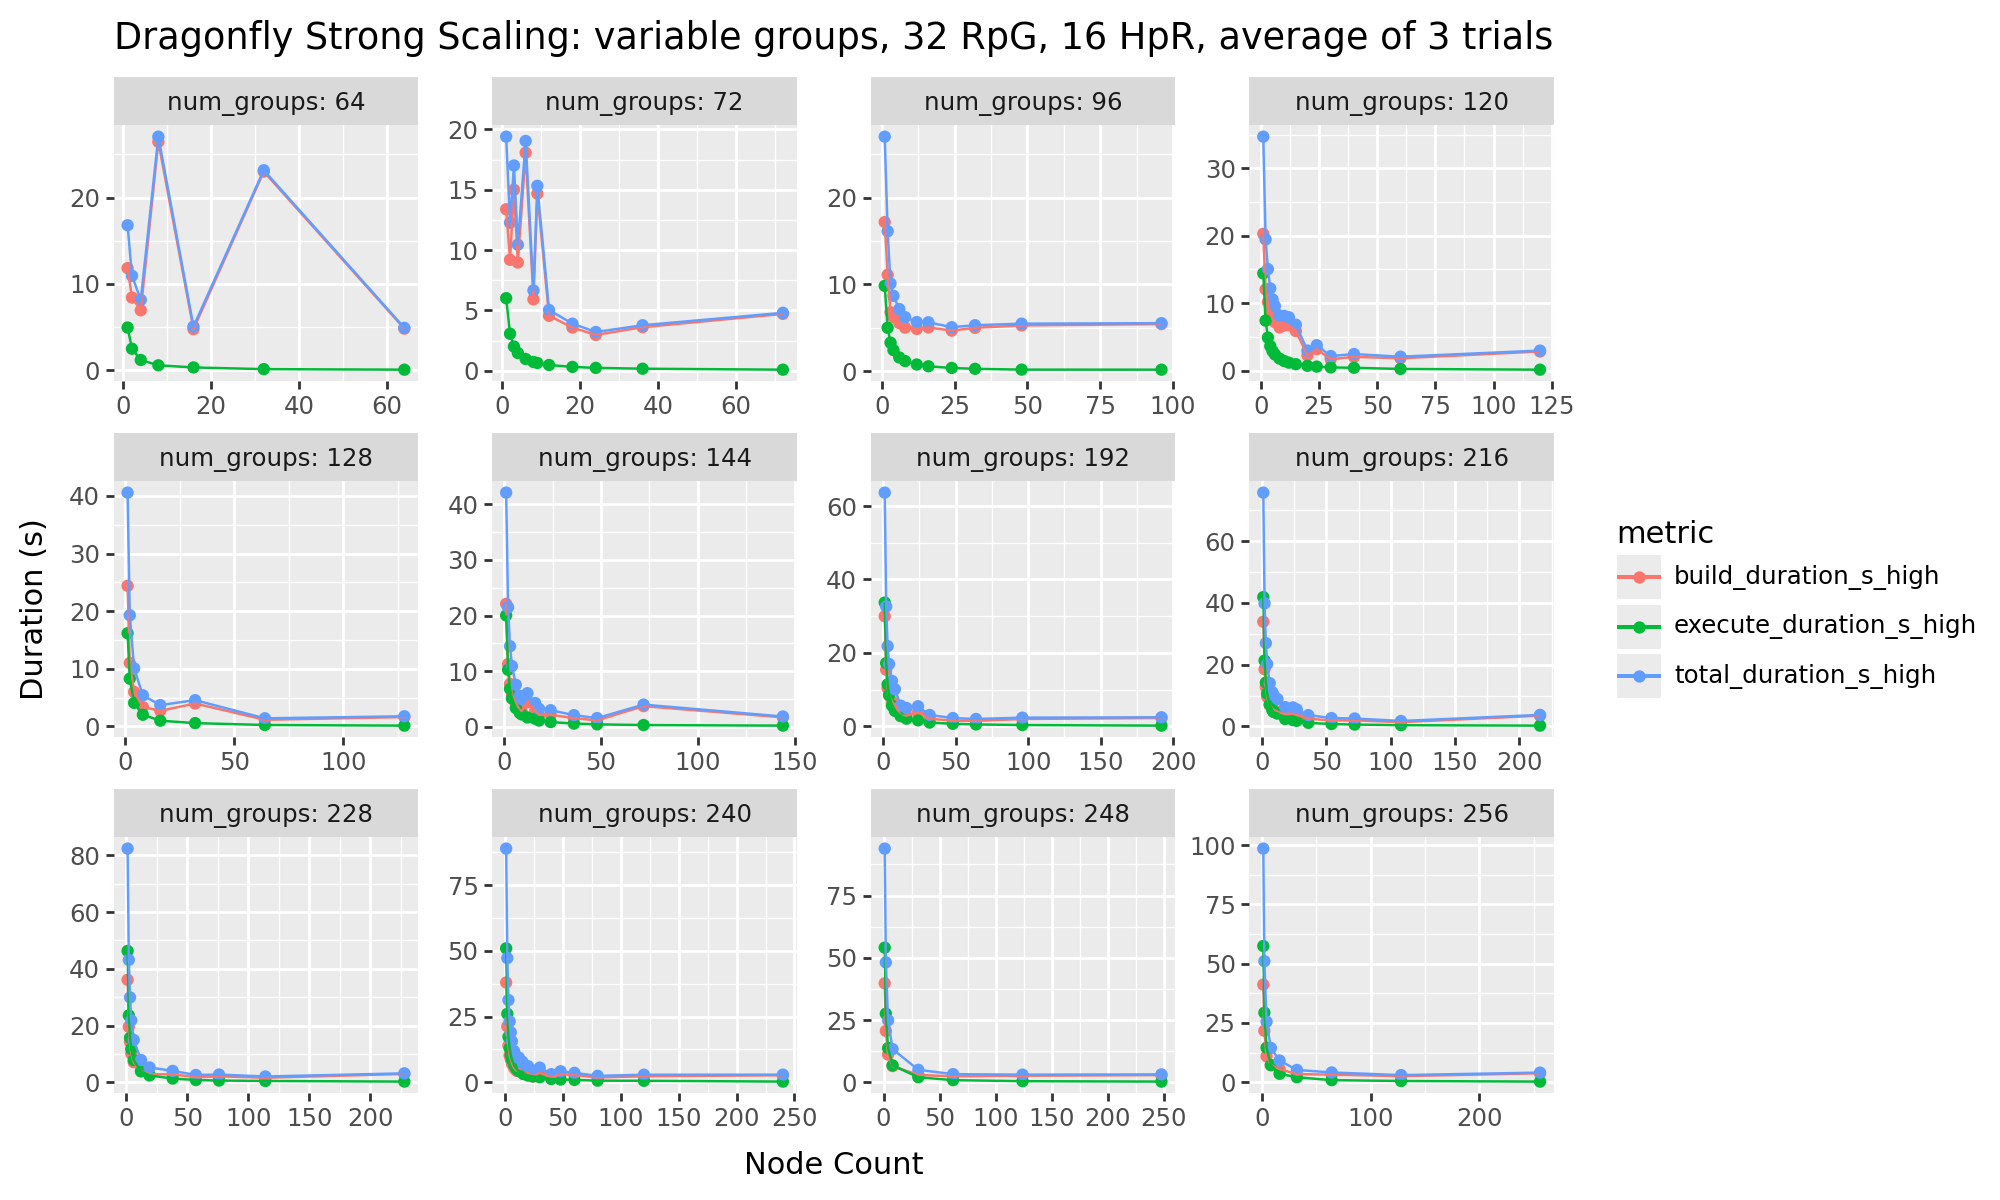

In [61]:

p = ggplot(time_df_high, aes(x='node_count', y='duration_s', color='metric'))
p += geom_point()
p += geom_line()
p += facet_wrap('~num_groups', scales='free', labeller = 'label_both')
#p += scale_y_continuous(limits=(0, df[['build_duration_s', 'execute_duration_s', 'total_duration_s']].max().max()))
p += labs(title="Dragonfly Strong Scaling: variable groups, 32 RpG, 16 HpR, average of 3 trials",
          x='Node Count', y='Duration (s)')
p += theme(figure_size=(10,6))

p

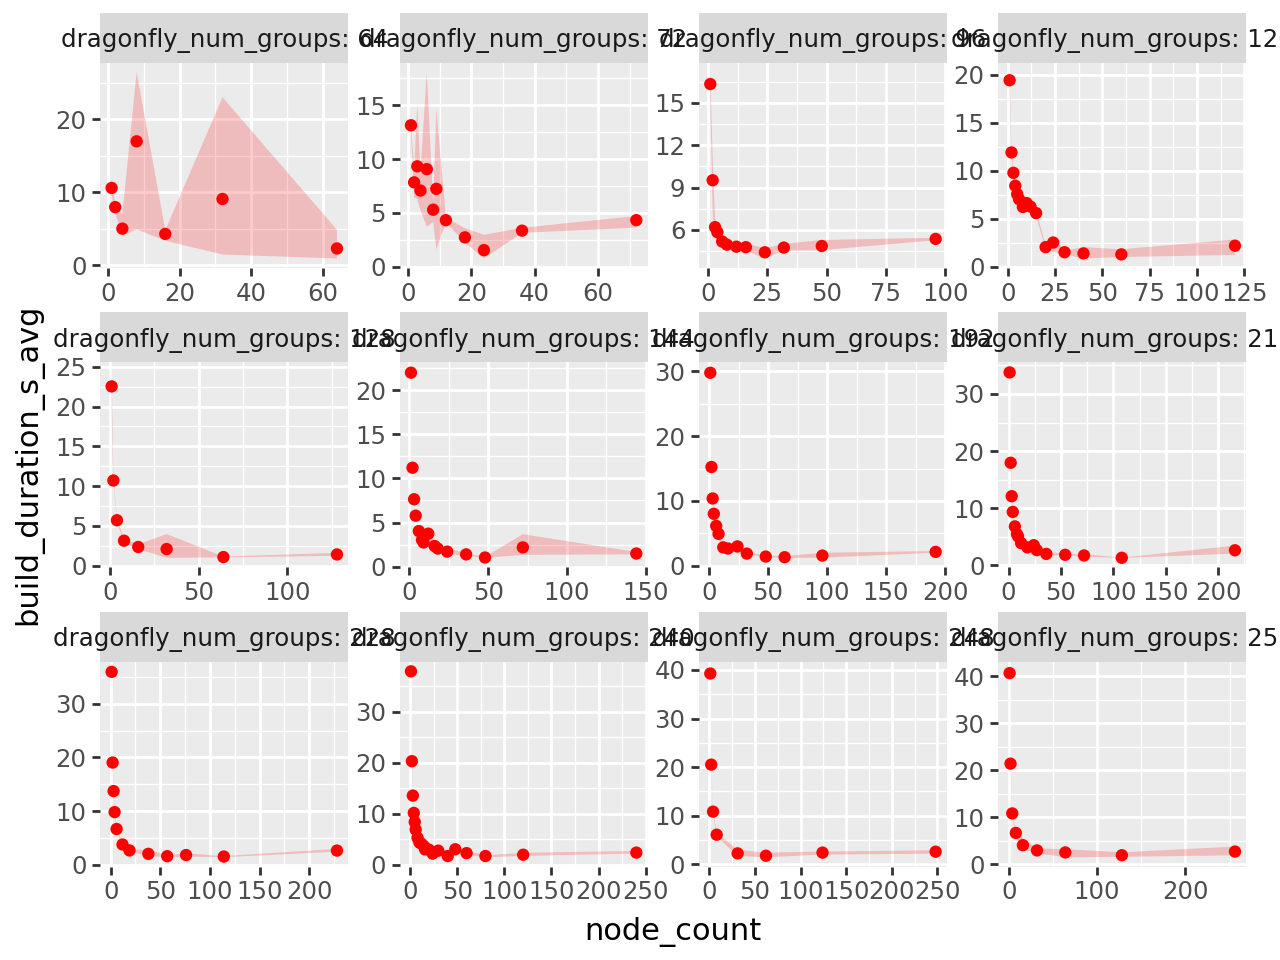

In [62]:
p = ggplot(df_agg, aes(x='node_count'))
p += geom_point(aes(y='build_duration_s_avg'), color='red')
p += geom_ribbon(aes(ymin='build_duration_s_low', ymax='build_duration_s_high'), alpha=0.2, fill='red')
p += facet_wrap('~dragonfly_num_groups', scales='free', labeller='label_both')
p

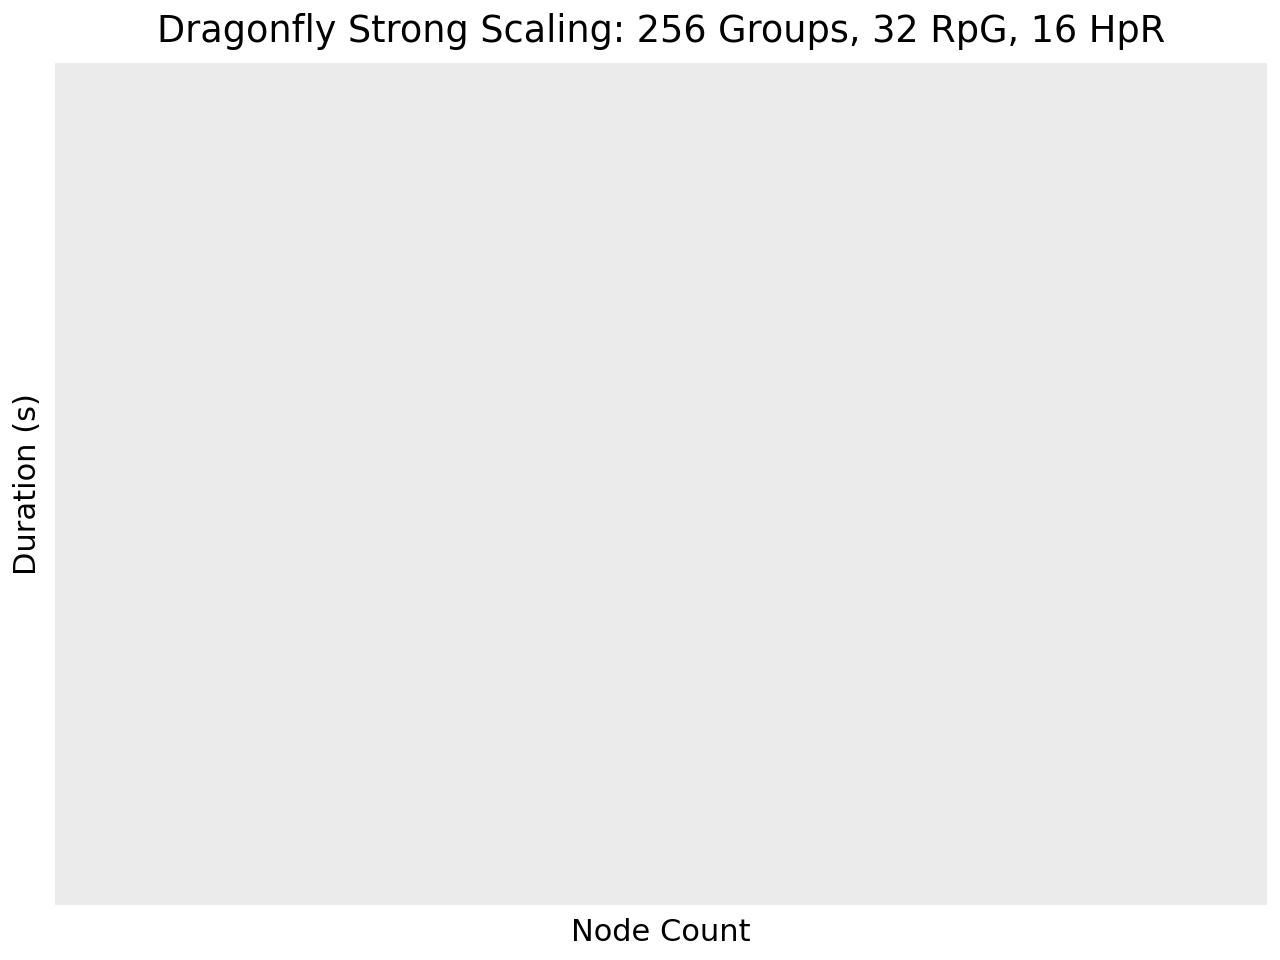

In [63]:
p = ggplot(time_df[time_df['dragonfly_num_groups'] == 256], aes(x='node_count', y='duration_s', color='metric'))
p += geom_point()
p += geom_line()
p += labs(title='Dragonfly Strong Scaling: 256 Groups, 32 RpG, 16 HpR', 
          x='Node Count', y='Duration (s)',)
p += scale_color_discrete(
    name="Time Period",
    labels={"build_duration_s": "Build Phase", "execute_duration_s": "Execute Phase", "total_duration_s": "Total Simulation"},
)
p

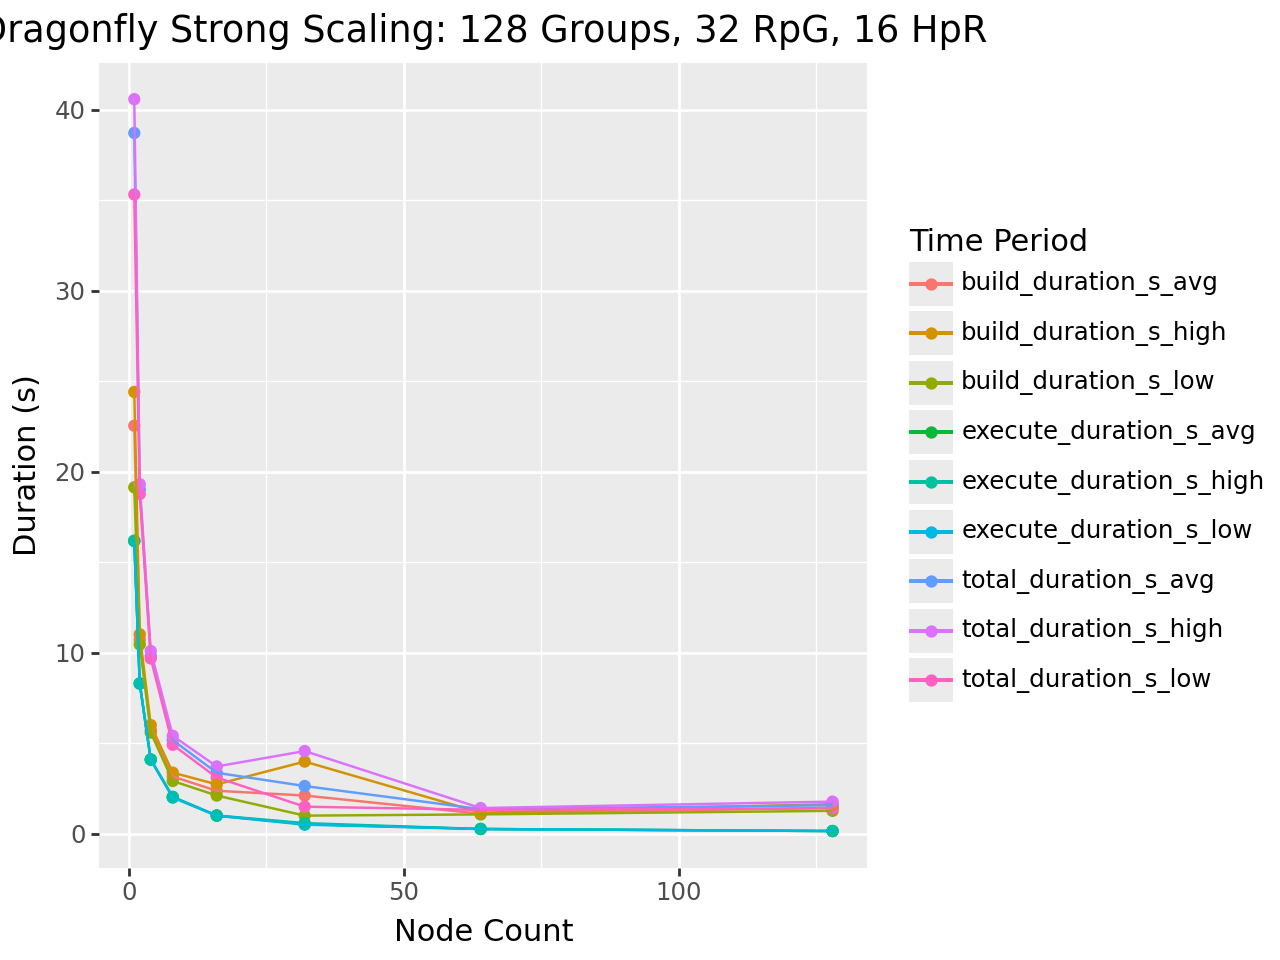

In [64]:
p = ggplot(time_df[time_df['dragonfly_num_groups'] == 128], aes(x='node_count', y='duration_s', color='metric'))
p += geom_point()
p += geom_line()
p += labs(title='Dragonfly Strong Scaling: 128 Groups, 32 RpG, 16 HpR', 
          x='Node Count', y='Duration (s)',)
p += scale_color_discrete(
    name="Time Period",
    labels={"build_duration_s": "Build Phase", "execute_duration_s": "Execute Phase", "total_duration_s": "Total Simulation"},
)
p

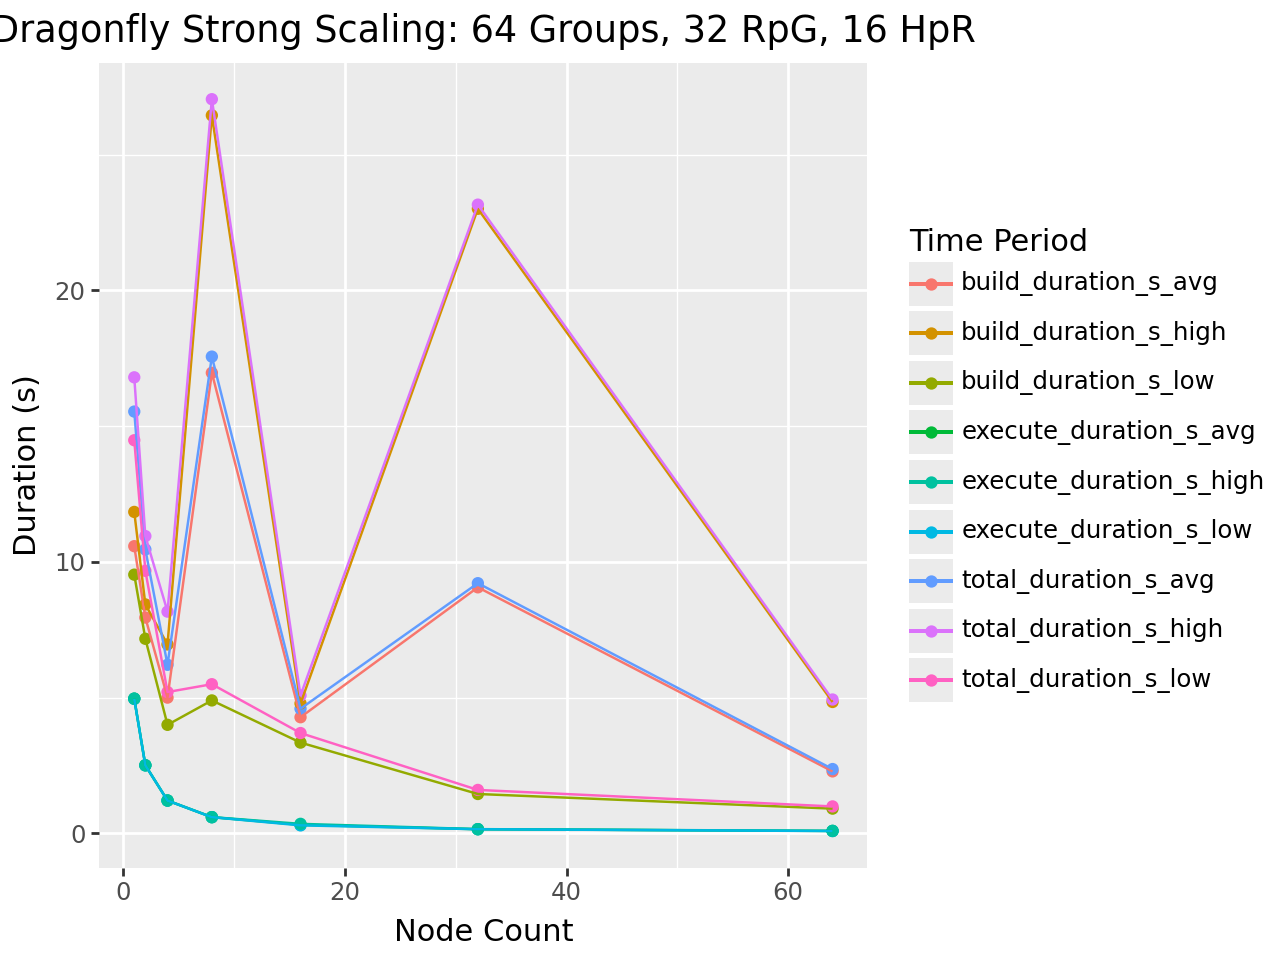

In [65]:
p = ggplot(time_df[time_df['dragonfly_num_groups'] == 64], aes(x='node_count', y='duration_s', color='metric'))
p += geom_point()
p += geom_line()
p += labs(title='Dragonfly Strong Scaling: 64 Groups, 32 RpG, 16 HpR', 
          x='Node Count', y='Duration (s)',)
p += scale_color_discrete(
    name="Time Period",
    labels={"build_duration_s": "Build Phase", "execute_duration_s": "Execute Phase", "total_duration_s": "Total Simulation"},
)
p